# CODE OVERVIEW

This code was developed by **Aritra Roy**, former *S.N. Bhatt Memorial Excellence Fellow (2024)* at the [International Centre for Theoretical Sciences (ICTS-TIFR), Bangalore](https://www.icts.res.in/news/results-icts-s-n-bhatt-memorial-excellence-fellowship-program-2024). I started writing this code during the winter intership at IISC Bangalore supervised by Prof Rahul Pandit as an intern on active matter systems.

---
# 2D Active Fluid Turbulence Solver (Pseudo-Spectral Method):
This notebook implements a fully dealiased pseudo-spectral solver to simulate a two-dimensional generalized active fluid model exhibiting chaotic, turbulent-like states. The flow is simulated in a square, doubly periodic domain $T^2 = [0, 2\pi) \times [0, 2\pi)$ mapped onto an $N \times N$ equidistant Fourier grid.

# Governing Equations 💡
The mathematical framework implemented in this simulation solves the generalized active-matter vorticity equation. We use the mean-bacterial velocity formulation using the Toner-Tu-Swift-Hohenberg (TTSH) model, for the incompressible velocity field $\mathbf{u}(\mathbf{x},t)$. 

Kiran, K. V., Gupta, A., Verma, A. K., & Pandit, R. (2023). Irreversibility in bacterial turbulence: Insights from the mean-bacterial-velocity model. *Physical Review Fluids*, 8, 023102. [https://doi:10.1103/PhysRevFluids.8.023102]

The system couples classical hydrodynamic advection with a linear instability mechanism representing localized energy injection from biological or active agents and a cubic nonlinear active friction tensor:
$$\frac{\partial \mathbf{u}}{\partial t} + \lambda_0 (\mathbf{u} \cdot \nabla)\mathbf{u} = -\nabla p - \alpha \mathbf{u} + \Gamma_2 \nabla^2 \mathbf{u} - \Gamma_4 \nabla^4 \mathbf{u} - \beta \vert\mathbf{u}\vert^2 \mathbf{u}$$

Taking the curl ($\nabla \times$) of this velocity equation eliminates the pressure gradient field ($\nabla \times \nabla p = 0$) and yields the scalar vorticity equation for $\omega = \nabla \times \mathbf{u}$:

$$\frac{\partial \omega}{\partial t} + \lambda_0 (\mathbf{u} \cdot \nabla)\omega = -\alpha \omega - \Gamma_2 \nabla^2 \omega - \Gamma_4 \nabla^4 \omega - \beta \nabla \times \left(|\mathbf{u}|^2 \mathbf{u}\right)$$

In this governing equation, $\omega(\mathbf{x},t)$ represents the scalar vorticity field, which describes the local spinning motion of the active fluid, while $\mathbf{u} = (u, v)$ denotes the two-dimensional mean-bacterial velocity vector field. To mathematically guarantee flow incompressibility ($\nabla \cdot \mathbf{u} = 0$), we introduce the hydrodynamic streamfunction $\psi(\mathbf{x},t)$, which relates directly to the velocity components through the spatial gradients $u = \frac{\partial \psi}{\partial y}$ and $v = -\frac{\partial \psi}{\partial x}$. Consequently, the scalar vorticity and the streamfunction are coupled kinematically through the two-dimensional Poisson equation $\nabla^2 \psi = -\omega$, meaning the vorticity field is defined fundamentally as $\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, clear_output

## 1. Active Matter Control Parameters

| Parameter | Value  | Description |
|-----------|--------|-------------|
| `lam0` | 3.5    | **Advection tuning multiplier** – scales the non-linear advective transport velocity relative to background flow. It explicitly breaks Galilean invariance ($\lambda_0 \neq 1$), which is a fundamental consequence of the self-propulsive forces in dense bacterial suspensions. A value of 3.5 enhances non-linear vortex stretching, breaking apart stable structures to promote chaotic, turbulent-like states. |
| `alpha`   | 1.0    | **Linear Rayleigh friction** – large-scale energy dissipation sink. It models momentum loss caused by friction against the supporting substrate or background fluid drag. By damping low-wavenumber (large-scale) structures, it prevents an unphysical accumulation of kinetic energy at the largest scales of the periodic domain. |
| `Gamma2`  | 0.045  | **Negative viscosity coefficient** – handles the primary active energy injection mechanism. Since $\Gamma_2 > 0$, it acts as a anti-diffusive source that destabilizes intermediate spatial frequencies and pumps kinetic energy directly into active bacterial scales. It serves as the primary engine driving the linear instability. |
| `Gamma4`  | 9e-5   | **Hyperviscosity coefficient** – high-order small-scale dissipation operator. It functions as a structural subgrid sink that heavily suppresses extreme high-wavenumber fluctuations. This fine-scale regularizer ensures that grid-scale energy yields a smooth, physically resolvable drop-off in the kinetic energy spectrum without numerical instability. |
| `beta`    | 0.5    | **Nonlinear active friction** – regulates the cubic velocity saturation tensor, $\beta \nabla \times \left(\|\mathbf{u}\|^2 \mathbf{u}\right)$. It provides a local drag penalty that scales with the cube of the velocity, acting as a non-linear brake. This coefficient ensures that the exponential growth driven by the negative viscosity reaches a bounded equilibrium. |

---

# Simulation Domain & DiscretizationComputational Domain ($L_x = L_y = 2\pi$):
A square, doubly periodic domain where the flow wraps seamlessly in both directions.Using multiples of $\pi$ sets the fundamental wavenumber to $1$, simplifying the Fourier transforms.Eliminates complex wall boundary conditions (no-slip, inflow/outflow), isolating pure homogeneous turbulence and internal wave dynamics.

# Grid Resolution ($N_x = N_y = 2048$):
Generates a regular Cartesian mesh totaling $4,194,304$ grid points ($N_{xy}$) per physical field.Crucial for resolving the smallest dissipation scales (Kolmogorov scale). Isotropic Grid Spacing ($\Delta x = \Delta y \approx 0.00307$):Perfectly uniform spacing ensures unbiased resolution for isotropic multi-scale features.Guarantees a high Nyquist cut-off wavenumber ($k_{max} = \frac{\pi}{\Delta x} \approx 1024$) to fully capture dissipative scales before numerical truncation.

In [2]:
# =============================================================================
# 1. SIMULATION & ACTIVE MATTER PARAMETERS
# =============================================================================
lam0 = 3.5        # Advection multiplier
alpha = 1         # Linear Rayleigh friction
beta = 0.5        # Nonlinear active friction
Gamma2 = 0.045    # Active energy injection parameter
Gamma4 = 9e-5     # Hyperviscosity (damping of small scales)

Lx = 2 * np.pi
Ly = 2 * np.pi
Nx = 2048          # Resolution grid
Ny = 2048
dx = Lx / Nx
dy = Ly / Ny

## 2. Grid, Spectral Operators & Dealiasing Pipeline 🛠️

This section of the solver establishes the discrete Fourier wavenumber spaces and precomputes the spectral differential operators. By converting spatial derivatives into localized algebraic multiplications, it forms the mathematical core of the pseudo-spectral engine.

### Mathematical Formulation
In Fourier space, the spatial gradient operator $\nabla$ maps directly to $j\mathbf{k} = (j k_x, j k_y)$, where $j = \sqrt{-1}$. Consequently, the Laplacian and bi-Laplacian operators transform as follows:

$$\nabla^2 \longrightarrow -k^2 = -(k_x^2 + k_y^2)$$
$$\nabla^4 \longrightarrow k^4 = (k_x^2 + k_y^2)^2$$

To reconstruct the incompressible velocity field $\mathbf{u} = (u,v)$ from the scalar vorticity field $\hat{\omega}$, we invoke the kinematic streamfunction definition ($\nabla^2 \psi = -\omega$). Inverting the Laplacian yields $\hat{\psi}(\mathbf{k}) = k^{-2}\hat{\omega}(\mathbf{k})$. The components of the velocity field are then evaluated directly via spatial gradients of the streamfunction ($u = \frac{\partial \psi}{\partial y}$ and $v = -\frac{\partial \psi}{\partial x}$):

$$\hat{u}(\mathbf{k}) = j k_y \hat{\psi}(\mathbf{k}) = j k_y k^{-2} \hat{\omega}(\mathbf{k})$$
$$\hat{v}(\mathbf{k}) = -j k_x \hat{\psi}(\mathbf{k}) = -j k_x k^{-2} \hat{\omega}(\mathbf{k})$$

---

### The 1/2 Dealiasing Rule (Cubic Nonlinearity Cutoff)
When computing the non-linear active friction term $\beta \nabla \times (|\mathbf{u}|^2 \mathbf{u})$ in physical space, the multiplication of field arrays triggers a triple convolution in the spectral domain. While a standard quadratic advection term requires only the traditional $2/3$ dealiasing rule ($k_{max} = N/3$) to prevent high-frequency spectral wrapping, a <span style="color:magenta;">**cubic nonlinearity requires a strict $1/2$ dealiasing rule**</span>. 

To completely eliminate aliasing errors, all active spectral configurations are truncated beyond the structural threshold:

$$\vert k_x \vert > \frac{N}{4} \quad \text{and} \quad \vert k_y \vert > \frac{N}{4}$$

---

### Spectral Array and Operator Map

| Variable | Mathematical Symbol | Role & Technical Implementation |
|----------|---------------------|---------------------------------|
| `kx_raw`, `ky_raw` | $k_{x, \text{raw}}, k_{y, \text{raw}}$ | **Raw Fourier Wavenumbers** – Generated using `np.fft.fftfreq`, scaled by the domain lengths to establish the exact physical periodicity of the discrete grid steps. |
| `dealias_mask` | $\mathcal{M}(\mathbf{k})$ | **Sharp Binary Low-Pass Filter** – A matrix filled with ones inside the safe grid zone ($\le N/4$) and zeros everywhere else, acting as a subgrid safeguard against non-linear aliasing blowups. |
| `K2` | $k^2 = k_x^2 + k_y^2$ | **Fourier-Space Laplacian Matrix** |
| `K4` | $k^4 = (k_x^2 + k_y^2)^2$ | **Fourier-Space Bi-Laplacian Matrix** – Essential for evaluating the scale-selective hyperviscous damping term ($\Gamma_4 \nabla^4 \omega$). |
| `K2inv` | $k^{-2}$ | **Inverse Laplacian Operator** – Explicitly zeroed out at the <span style="color:magenta;">**singular DC mode ($k_x=0, k_y=0$)**</span> to prevent division-by-zero errors, effectively enforcing a zero net-mass flow constraint on the periodic box. |
| `Dx`, `Dy` | $\mathcal{D}_x = \frac{j k_x}{k^2}$, $\mathcal{D}_y = \frac{j k_y}{k^2}$ | <span style="color:magenta;">**Velocity Reconstruction Operators**</span> – Precomputed complex projection arrays that directly map the scalar vorticity matrix to the directional velocity fields during the non-linear evaluation loop. |

In [3]:
# =============================================================================
# 2. GRID, SPECTRAL OPERATORS & 1/2 DEALIASING
# =============================================================================
kx_raw = np.fft.fftfreq(Nx, d=dx / (2 * np.pi))
ky_raw = np.fft.fftfreq(Ny, d=dy / (2 * np.pi))
Kx_raw, Ky_raw = np.meshgrid(kx_raw, ky_raw, indexing='xy')

# Strict 1/2 dealiasing rule (N/4 cutoff) required for the cubic nonlinearity
dealias_mask = (np.abs(Kx_raw) <= (Nx / 4)) & (np.abs(Ky_raw) <= (Ny / 4))

# Apply mask to the active computational wavenumbers
Kx = Kx_raw * dealias_mask
Ky = Ky_raw * dealias_mask
K2 = Kx**2 + Ky**2
K4 = K2**2

K2inv = np.zeros_like(K2)
K2inv[K2 != 0] = 1.0 / K2[K2 != 0]

# Velocity reconstruction operators: u = i*ky/k² * ω, v = -i*kx/k² * ω
Dx = 1j * Kx * K2inv
Dy = 1j * Ky * K2inv

## 3. The Linear Operator & TTSH Physical Origins 🧬

This section of the code precomputes the diagonal linear operator matrix in Fourier space. Isolating this operator is computationally essential because it separates the stiff, high-order linear derivatives from the non-linear advective and active friction terms, enabling highly stable explicit time-integration.

### Connection to the Toner-Tu-Swift-Hohenberg (TTSH) Model
The structural form of this operator originates directly from the continuous momentum equation of the **Toner-Tu-Swift-Hohenberg (TTSH)** model for an incompressible active fluid vorticity field $\omega(\mathbf{x},t)$:

$$\frac{\partial \omega}{\partial t} + \lambda_0 (\mathbf{u} \cdot \nabla)\omega = \underbrace{-\alpha \omega - \Gamma_2 \nabla^2 \omega - \Gamma_4 \nabla^4 \omega}_{\text{Linear Terms}} - \beta \nabla \times \left(\vert\mathbf{u}\vert^2 \mathbf{u}\right)$$

---

### Fourier Domain Derivation
Applying a spatial Fourier transform ($\mathcal{F}$) converts the spatial differential operators into algebraic expressions. Substituting the transform identities $\nabla^2 \longrightarrow -k^2$ and $\nabla^4 \longrightarrow k^4$ into the linear terms on the right-hand side yields:

$$\mathcal{F}\left\{ -\alpha \omega - \Gamma_2 \nabla^2 \omega - \Gamma_4 \nabla^4 \omega \right\} = -\alpha \hat{\omega} - \Gamma_2 (-k^2)\hat{\omega} - \Gamma_4 (k^4)\hat{\omega}$$

Factoring out the spectral vorticity mode $\hat{\omega}(\mathbf{k}, t)$ reveals the exact algebraic multiplier implemented in the code:

$$\hat{L}(\mathbf{k}) = -\alpha + \Gamma_2 k^2 - \Gamma_4 k^4$$

Notice that the sign of the <span style="color:magenta;">**negative viscosity term switches to positive ($+\Gamma_2 k^2$)**</span> due to the identity $j^2 = -1$, exposing its role as a linear energy pumper, while the <span style="color:magenta;">**hyperviscosity term preserves its negative sign ($-\Gamma_4 k^4$)**</span> via $j^4 = 1$, acting as a powerful high-wavenumber dampener.

---

### Linear Operator Component Map

| Code Variable | Mathematical Term | Spectral Role & Physical Mechanism |
|---------------|-------------------|------------------------------------|
| `-alpha` | $-\alpha$ | <span style="color:magenta;">**Large-Scale Energy Sink**</span> – Uniformly dampens all Fourier modes. It dominates at the smallest active wavenumbers ($k \to 0$), ensuring that background friction bounds large, domain-sized box vortices. |
| `Gamma2 * K2` | $+\Gamma_2 k^2$ | <span style="color:magenta;">**Active Wave Band Instability**</span> – Acts as a negative viscosity mechanism. It drives exponential mode growth at intermediate scales, serving as the biological engine that feeds kinetic energy into the fluid. |
| `-Gamma4 * K4` | $-\Gamma_4 k^4$ | <span style="color:magenta;">**Hyperviscous Spectral Regularizer**</span> – Scales severely with the fourth power of the wavenumber. It guarantees numerical stiffness control by rapidly killing off grid-scale oscillations ($k \to k_{max}$). |

---

### Numerical Stability Impact
Because hyperviscosity depends on $k^4$, treating this operator explicitly in physical space would require a prohibitively tiny, unfeasible time step ($dt \propto dx^4$). Precomputing `Linear_Op` in Fourier space allows the solver to integrate the stiff linear dynamics <span style="color:magenta;">**analytically and exactly**</span> via exponential Integrating Factors ($e^{\hat{L}dt}$), removing the hyperviscous stability restriction from the global Courant-Friedrichs-Lewy (CFL) condition.

In [4]:
# Linear Operator (L) in Fourier Space
Linear_Op = -alpha + (Gamma2 * K2) - (Gamma4 * K4)

## 4. Time Integration & The Integrating Factor Method (IF-RK4) ⏳

This block implements the **Integrating Factor 4th-Order Runge-Kutta (IF-RK4)** explicit time-stepping scheme coupled with a pseudo-spectral non-linear evaluation pipeline. This mathematical framework is designed to overcome structural numerical constraints while ensuring high-order temporal accuracy.

### Mathematical Principle of the Integrating Factor

When transformed into Fourier space, our active-matter governing equation forms a system of coupled ordinary differential equations (ODEs) for each spatial wavenumber $\mathbf{k}$:

$$\frac{\partial \hat{\omega}}{\partial t} = \hat{L}(\mathbf{k})\hat{\omega} + \hat{N}(\hat{\omega})$$

Here, $\hat{L}(\mathbf{k}) = -\alpha + \Gamma_2 k^2 - \Gamma_4 k^4$ represents the stiff linear operator, and $\hat{N}(\hat{\omega})$ gathers the non-linear advection and active cubic stress terms. 

If treated with a standard explicit scheme, the high-order spatial derivatives contained within $\hat{L}$ (specifically the hyperviscous $k^4$ term) enforce a disastrously restrictive Courant-Friedrichs-Lewy (CFL) constraint on the time-step size, requiring $dt \propto dx^4$. To bypass this, we utilize an **Integrating Factor** transformation. We isolate the linear terms on the left-hand side:

$$\frac{\partial \hat{\omega}}{\partial t} - \hat{L}\hat{\omega} = \hat{N}(\hat{\omega})$$

Multiplying the entire equation by the integrating factor $e^{-\hat{L}t}$ allows us to rewrite the left-hand side as a single, exact total derivative via the product rule:

$$e^{-\hat{L}t}\frac{\partial \hat{\omega}}{\partial t} - \hat{L}e^{-\hat{L}t}\hat{\omega} = \frac{\partial}{\partial t}\left( e^{-\hat{L}t}\hat{\omega} \right) = e^{-\hat{L}t}\hat{N}(\hat{\omega})$$

By introducing a transformed, un-stiffened vorticity variable $\hat{\Omega}(t) = e^{-\hat{L}t}\hat{\omega}(t)$, the equation simplifies to:

$$\frac{\partial \hat{\Omega}}{\partial t} = e^{-\hat{L}t}\hat{N}\left(e^{\hat{L}t}\hat{\Omega}\right)$$

In this transformed frame, <span style="color:magenta;">**the stiff linear terms are integrated analytically and exactly**</span>. The numerical stability constraint is now governed purely by the lower-order, smooth non-linear advective flow field rather than grid-scale grid oscillations.

---

### Discrete Multi-Stage IF-RK4 Logic

To advance the state from time step $t_n$ to $t_{n+1} = t_n + dt$, we apply the classical 4th-order Runge-Kutta weights to the transformed variable $\hat{\Omega}$, and then project the solution back to physical vorticity space $\hat{\omega}$. 

To minimize computational overhead inside the solver loop, we precompute the half-step and full-step exponential integration operators once outside the time loop:
* `E` $= e^{\hat{L}\,dt / 2}$
* `E2` $= e^{\hat{L}\,dt}$

The four discrete stages implemented in the code translate to the following mathematical balance:

$$\hat{N}_1 = \hat{N}(\hat{\omega}_n)$$
$$\hat{N}_2 = \hat{N}\left( E\hat{\omega}_n + \frac{dt}{2}E\hat{N}_1 \right)$$
$$\hat{N}_3 = \hat{N}\left( E\hat{\omega}_n + \frac{dt}{2}\hat{N}_2 \right)$$
$$\hat{N}_4 = \hat{N}\left( E2\hat{\omega}_n + dt\,E\hat{N}_3 \right)$$

The complete, conservation-preserving state update vector is then evaluated as:

$$\hat{\omega}_{n+1} = E2\hat{\omega}_n + \frac{dt}{6}\left[ E2\hat{N}_1 + 2E\hat{N}_2 + 2E\hat{N}_3 + \hat{N}_4 \right]$$

---

### Non-Linear Evaluation Pipeline (`Calc_Nonlinear`)

Because convolutions are prohibitively expensive to compute directly in the spectral domain, the function `Calc_Nonlinear` executes a **pseudo-spectral loop**. It systematically transforms fields back and forth between physical and Fourier space to execute spatial derivative operations and algebraic multiplications where they are cheapest.

| Step | Operation Type | Code Implementation & Mathematical Mapping |
| :--- | :--- | :--- |
| **1** | Spectral Differentiation & Inverse FFT | <span style="color:magenta;">**Reconstruct real-space kinematic gradients and velocities**</span>:<br>$\partial_x \omega = \mathcal{F}^{-1}(j k_x \hat{\omega})$<br>$\partial_y \omega = \mathcal{F}^{-1}(j k_y \hat{\omega})$<br>$u = \mathcal{F}^{-1}(\mathcal{D}_y \hat{\omega}) \quad \text{and} \quad v = \mathcal{F}^{-1}(-\mathcal{D}_x \hat{\omega})$ |
| **2** | Real-Space Array Multiplication | **Evaluate localized non-linear interactions**:<br>$\text{advection} = -\lambda_0 (u \partial_x \omega + v \partial_y \omega)$<br>$\mathbf{F} = \vert\mathbf{u}\vert^2 \mathbf{u} \longrightarrow \begin{cases} F_x = (u^2 + v^2)u \\ F_y = (u^2 + v^2)v \end{cases}$ |
| **3** | Forward FFT & Spectral Curl | **Transform tensors back to Fourier space and compute the curl of the active stress vector**:<br>$\hat{F}_x = \mathcal{F}(F_x), \quad \hat{F}_y = \mathcal{F}(F_y)$<br>$\mathcal{F}\{\nabla \times \mathbf{F}\} = j k_x \hat{F}_y - j k_y \hat{F}_x$ |
| **4** | Dynamic Alias Filtering | **Combine active terms and apply the low-pass filter**:<br>$\hat{N} = \left[ \mathcal{F}(\text{advection}) - \beta \mathcal{F}\{\nabla \times \mathbf{F}\} \right] \times \mathcal{M}(\mathbf{k})$<br> This ensures <span style="color:magenta;">**strict elimination of high-frequency grid-aliasing errors**</span> before returning the vector to the RK4 integrator. |

In [5]:
# =============================================================================
# 3. INTEGRATING FACTOR (IF) OPERATORS
# =============================================================================
dt = 8e-3  # Microscopic stable time step size

# Precompute the exponential integrators for the linear terms
E = np.exp(Linear_Op * dt / 2.0)
E2 = np.exp(Linear_Op * dt)

# =============================================================================
# 4. THE NONLINEAR RHS EVALUATOR
# =============================================================================
def Calc_Nonlinear(Om_hat):
    """
    Computes only the convective advection and active stress terms in Fourier space.
    """
    # 1. Compute spatial gradients and reconstruct velocities
    Omx = np.real(ifft2(1j * Kx * Om_hat))
    Omy = np.real(ifft2(1j * Ky * Om_hat))
    u = np.real(ifft2(Dy * Om_hat))
    v = np.real(ifft2(-Dx * Om_hat))

    # 2. Evaluate real-space nonlinear active stresses
    advection = -lam0 * (u * Omx + v * Omy)
    V2 = u**2 + v**2
    Fx = V2 * u
    Fy = V2 * v
    
    # 3. Transform back to Fourier Space and take the curl
    Fx_hat = fft2(Fx)
    Fy_hat = fft2(Fy)
    curl_F_hat = 1j * Kx * Fy_hat - 1j * Ky * Fx_hat
    
    # 4. Combine and strictly dealias the final nonlinear tensor
    N_hat = fft2(advection) - beta * curl_F_hat
    N_hat *= dealias_mask
    
    return N_hat

## 5. Initial Condition & Visualization Protocol 🧪

This block configures the initial state of the active fluid and sets up the temporal pacing for the real-time visualization loop. It ensures the simulation starts from a mathematically stable state and throttles graphics updates to preserve computational efficiency.

### Spectral Initialization Strategy
To kickstart chaotic active-matter turbulence, the system is seeded with broad-spectrum white noise in physical space. When transformed into the Fourier domain, this raw noise contains mathematical energy across all wavelengths. To prevent immediate numerical divergence, a dual-layer filtering pipeline is applied:
1. **Alias Prevention:** The array is multiplied by `dealias_mask` to enforce the strict $N/4$ subgrid cutoff.
2. **Shock Suppression:** High-frequency spatial fluctuations are aggressively truncated by a sharp spectral low-pass filter <span style="color:magenta;">**($k^2 > 100$)**</span>. This ensures that unphysical, infinitely sharp gradients do not induce numerical shockwaves or disrupt the stiff integrating factor calculations during the initial time steps.

---

### Field Initialization & Visualization Map

| Variable | Default Value | Technical Role & Physics Interpretation |
| :--- | :--- | :--- |
| `np.random.seed(42)` | `42` | **Pseudo-Random Number Seed** – Guarantees exact reproducibility across independent numerical simulation runs. |
| `Om_initial` | `randn(Ny, Nx)` | **Physical Vorticity Seed** – Generates a Gaussian white noise vorticity landscape to provide an unbiased distribution of initial flow perturbations. |
| `Om_hat` | $\hat{\omega}(\mathbf{k}, t=0)$ | <span style="color:magenta;">**Filtered Initial Spectral State**</span> – The clean, dealiased, low-frequency-bounded vorticity matrix used as the true starting vector for the IF-RK4 integration loop. |
| `t` | `0.0` | **Initial Simulation Time** – Tracks cumulative physical time elapsed in the fluid domain. |
| `Tf` | `20.0` | **Terminal Integration Time** – Establishes the temporal boundary at which the active-matter solver stops. |
| `ds` | `0.25` | **Visualization Sampling Window ($\Delta t_{\text{plot}}$)** – Dictates the physical time interval separating successive frame refreshes or file exports. |
| `steps_per_plot` | $\Delta t_{\text{plot}} / dt$ | <span style="color:magenta;">**Temporal Stride Control**</span> – Translates the smooth physical visualization interval into a discrete number of numerical iterations. The solver advances exactly this many steps before pausing to redraw the canvas or save a snapshot, dramatically slashing I/O bottlenecks. |

In [6]:
# =============================================================================
# 5. INITIAL CONDITION
# =============================================================================
np.random.seed(42) 

# Generate broad-spectrum noise seeded safely in Fourier Space
Om_initial = np.random.randn(Ny, Nx)
Om_hat = fft2(Om_initial)
Om_hat *= dealias_mask
Om_hat[K2 > 100] = 0.0  # Soft cut-off filter to eliminate initial high-frequency shocks

# =============================================================================
# 6. VISUALIZATION SETUP & USER CUSTOM COLORMAP
# =============================================================================
t = 0.0
Tf = 20.0   
ds = 0.25   # Interval for updating the display plot
steps_per_plot = int(ds / dt)  

## 6. The High-Speed IF-RK4 Integration Loop 🏎️

This section implements the main execution loop of the simulation. It utilizes a nested loop structure designed to maximize throughput by separation of raw numerical computation from rendering input/output (I/O) operations, while executing the four mathematical stages of the Integrating Factor 4th-Order Runge-Kutta algorithm.

### Multi-Stage Update Mechanics
Because the linear operator is integrated analytically via the exponential matrices `E` ($e^{\hat{L}\Delta t/2}$) and `E2` ($e^{\hat{L}\Delta t}$), the Runge-Kutta stages evaluate the non-linear trajectories across shifted phase spaces. The loop steps through four sequential operations:

1. **Stage 1 (Predictor):** Evaluates the initial non-linear RHS ($\hat{N}_1$) from the current state, then projects the vorticity vector to the half-timestep boundary ($t_n + \frac{dt}{2}$) using the half-step exponential mapping matrix `E`.
2. **Stage 2 (First Corrector):** Computes the non-linear derivative ($\hat{N}_2$) at this predicted half-step state, updating the intermediate vector while keeping the initial state historical reference.
3. **Stage 3 (Second Corrector):** Re-evaluates the non-linear profile ($\hat{N}_3$) at the corrected half-step, subsequently marching the state to the full-step horizon ($t_n + dt$) using the full-step integrator `E2`.
4. **Stage 4 & Final Weighted Averaging:** Extracts the final non-linear vector ($\hat{N}_4$) at the full-step estimation, combining all four structural derivatives using Simpson’s $\frac{1}{6}$ rule weights to compute a high-precision, conservation-preserving final update.

---

### Loop Optimization and Batching Logic
The algorithm relies on a <span style="color:magenta;">**dual-layered nested loop structure to minimize computational bottlenecks**</span>:
* **The Outer `while` Loop:** Governs macro-scale physical time progression up to the terminal threshold `Tf`.
* **The Inner `for` Loop:** Executes a localized batch of pure mathematical iterations equal to `steps_per_plot`. 

By executing a cluster of steps strictly within RAM before returning control to the outer loop, the engine <span style="color:magenta;">**decouples the subgrid time integration from the plotting canvas**</span>. This bypasses costly graphics pipeline stalls, enabling the pseudo-spectral solver to run at peak operational speed.

---

### Algorithmic Stepping and State Map

| Code Variable / Syntax | Mathematical Operation | Technical Role inside the Integration Engine |
| :--- | :--- | :--- |
| `Calc_Nonlinear(Om_hat)` | $\hat{N}(\hat{\omega})$ | **Pseudo-Spectral RHS Function** – Executes the forward/backward FFT pipelines to generate the dealiased advection and active stress curl vectors. |
| `N1`, `N2`, `N3`, `N4` | $\hat{N}_1, \hat{N}_2, \hat{N}_3, \hat{N}_4$ | <span style="color:magenta;">**Runge-Kutta Multi-Stage Tangent Vectors**</span> – Snapshots of the non-linear phase space gradients evaluated across the subgrid intervals. |
| `Om_hat_1` | $\hat{\omega}^{(1)} = E\hat{\omega}_n + \frac{dt}{2}E\hat{N}_1$ | **Half-Step Predictor** – Leverages `E` to analytically advance the linear components while appending the first non-linear guess. |
| `Om_hat_2` | $\hat{\omega}^{(2)} = E\hat{\omega}_n + \frac{dt}{2}\hat{N}_2$ | **Half-Step Corrector** – Refines the midpoint trajectory; note that `E` is omitted from the RHS addition here because $\hat{N}_2$ already shares the half-step phase space. |
| `Om_hat_3` | $\hat{\omega}^{(3)} = E2\hat{\omega}_n + dt E\hat{N}_3$ | **Full-Step Predictor** – Projects the system forward to the full time step boundary utilizing the macro-scale `E2` operator matrix. |
| `Om_hat` (Final Line) | $\hat{\omega}_{n+1}$ | <span style="color:magenta;">**Consolidated Time-Step Vector**</span> – Combines the exact exponential history of the linear modes with the weighted non-linear perturbations to form the final stable field entry. |
| `t += dt` | $t_{n+1} = t_n + dt$ | **Temporal Increment** – Uniformly steps the physical clock forward to maintain strict coherence with the numerical state. |

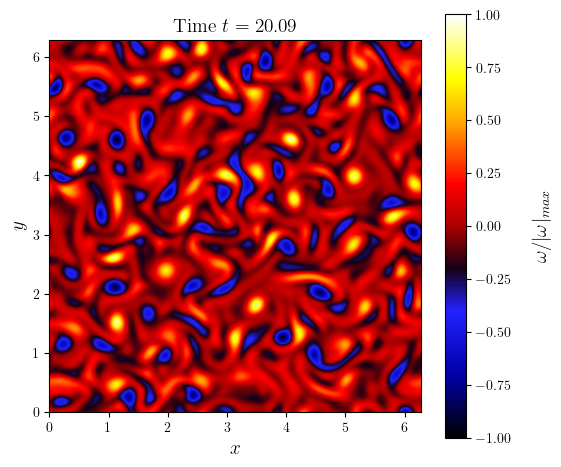

In [7]:
def create_custom_colormap():
    color_stops = [
        (0.00, '#000000'),  # Value: -1.0 | Black
        (0.15, '#0000AA'),  # Value: -0.7 | Medium Blue
        (0.30, '#2222FF'),  # Value: -0.4 | Bright Blue
        (0.40, '#150015'),  # Value: -0.2 | Dark sharp transition boundary
        (0.50, '#AA0000'),  # Value:  0.0 | Dark Red
        (0.60, '#FF0000'),  # Value:  0.2 | Bright Red
        (0.75, '#FFAA00'),  # Value:  0.5 | Orange
        (0.85, '#FFFF00'),  # Value:  0.7 | Yellow
        (1.00, '#FFFFFF')   # Value:  1.0 | White
    ]
    return LinearSegmentedColormap.from_list('turbulent_fire_ice_scaled', color_stops)

# Instantiate the user's updated scaled colormap
turbulent_fire_ice_scaled = create_custom_colormap()

plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
fig, ax = plt.subplots(figsize=(6, 5.5))

Om = np.real(ifft2(Om_hat))
im = ax.imshow(
    Om, extent=[0, Lx, 0, Ly], origin='lower',
    cmap=turbulent_fire_ice_scaled, vmin=-1.0, vmax=1.0  
)

# Set axes labels using LaTeX math mode formatting
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$y$', fontsize=14)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$\omega /|\omega|_{max}$', rotation=90, fontsize=14, labelpad=15)

# Clean title showing ONLY the running time parameter
title = ax.set_title(r'Time $t = {:.2f}$'.format(t), fontsize=14)

# =============================================================================
# 7. THE HIGH-SPEED IF-RK4 INTEGRATION LOOP
# =============================================================================
print("Launching Ultra-Precise IF-RK4 Spectral Engine...")

while t < Tf:
    # Perform subgrid time-steps before forcing a canvas redraw
    for _ in range(steps_per_plot):
        
        # Stage 1
        N1 = Calc_Nonlinear(Om_hat)
        Om_hat_1 = E * Om_hat + (dt / 2.0) * E * N1
        
        # Stage 2
        N2 = Calc_Nonlinear(Om_hat_1)
        Om_hat_2 = E * Om_hat + (dt / 2.0) * N2
        
        # Stage 3
        N3 = Calc_Nonlinear(Om_hat_2)
        Om_hat_3 = E2 * Om_hat + dt * E * N3
        
        # Stage 4 & Full State Update
        N4 = Calc_Nonlinear(Om_hat_3)
        Om_hat = E2 * Om_hat + (dt / 6.0) * (E2 * N1 + 2 * E * N2 + 2 * E * N3 + N4)
        
        t += dt

    # Invert the field back to real physical space
    Om = np.real(ifft2(Om_hat))
    
    # NORMALIZATION STEP: Force the field array values strictly between -1 and 1
    v_max = np.max(np.abs(Om))
    if v_max > 0:
        Om_plot = Om / v_max
    else:
        Om_plot = Om
    
    # Push normalized data safely into the plot canvas
    im.set_data(Om_plot)
    im.set_clim(-1.0, 1.0)  
    
    # Title displays ONLY the running simulation time
    title.set_text(r'Time $t = {:.2f}$'.format(t))
    
    clear_output(wait=True)
    display(fig)

plt.close()

## 7. Post-Processing: Isotropic Energy Spectrum & Active Fluid Physics 📊

This final stage of the pipeline converts the computed chaotic vorticity field into a normalized, one-dimensional omnidirectional kinetic energy spectrum $\mathcal{E}(k)$. By transforming the flow into its constituent spatial frequencies, this analysis uncovers the multi-scale mechanics, cascade pathways, and energy balances characteristic of bacterial turbulence.

### Mathematical Derivation of the 2D Energy Density
In an incompressible fluid, the kinetic energy per unit mass in the spectral domain is derived from the velocity vector field as $\hat{E}_{2D}(\mathbf{k}) = \frac{1}{2} \vert\hat{\mathbf{u}}(\mathbf{k})\vert^2$. Because the solver tracks the flow via the scalar vorticity field $\hat{\omega}(\mathbf{k})$, we utilize the kinematic relation linking velocity to vorticity through the Laplacian operator ($\hat{\mathbf{u}} = \mathbf{j}\mathbf{k} \times \hat{\psi}$ and $\hat{\omega} = -k^2 \hat{\psi}$). 

Substituting these operators yields the exact algebraic conversion implemented in the code:

$$\hat{E}_{2D}(\mathbf{k}) = \frac{1}{2} \left( \vert\hat{u}\vert^2 + \vert\hat{v}\vert^2 \right) = \frac{1}{2} \left( \frac{k_y^2}{k^4}\vert\hat{\omega}\vert^2 + \frac{k_x^2}{k^4}\vert\hat{\omega}\vert^2 \right) = \frac{1}{2} \frac{\vert\hat{\omega}(\mathbf{k})\vert^2}{k^2}$$

To preserve physical energy consistency when moving between the discrete Fourier grid and continuous space, **Parseval's identity** requires scaling by the square of the total grid dimensions, yielding the normalized computational density matrix:

$$E_{2D}(k_x, k_y) = \frac{1}{2} \frac{\vert\hat{\omega}(k_x, k_y)\vert^2}{(k_x^2 + k_y^2) \cdot (N_x N_y)^2}$$

---

### Isotropic Shell Integration (Radial Binning)
To compress the two-dimensional spectral map $E_{2D}(k_x, k_y)$ into a standard one-dimensional spectrum $E(k)$, the solver assumes statistical isotropy in the turbulent state. The code executes a radial shell integration by grouping discrete wavenumbers into concentric rings of unit width $\Delta k = 1$:

$$\mathcal{E}(k) = \sum_{k - 0.5 \le \vert\mathbf{k}\vert < k + 0.5} E_{2D}(k_x, k_y)$$

This omnidirectional integration accumulates the kinetic energy contained within all wave vectors pointing in any angular direction at a given spatial frequency magnitude $k = \sqrt{k_x^2 + k_y^2}$.

---

### Dimensionless Scaling and Active Fluid Physics

| Quantity / Symbol | Mathematical Definition | Physical Role & Active Matter Insights |
| :--- | :--- | :--- |
| `k_f` ($k_f$) | $\sqrt{\frac{\Gamma_2}{2\Gamma_4}}$ | **Peak Instability Wavenumber** – The exact spatial frequency where the linear active energy injection from biological agents is maximized before being overtaken by hyperviscosity. |
| `Lambda` ($\Lambda$) | $\frac{1}{k_f} = \sqrt{\frac{2\Gamma_4}{\Gamma_2}}$ | **Characteristic Active Length Scale** – Defines the spatial micro-scale footprint of individual bacterial vortex structures or coherent active networks. |
| `u_rms_sq` ($u_{\text{rms}}^2$) | $\langle u^2 + v^2 \rangle$ | <span style="color:magenta;">**Total Kinetic Energy Flux Variance**</span> – Evaluated in real space via spatial averaging, tracking the global intensity of the active turbulent fluctuations. |
| `k_scaled` | $k\Lambda$ | **Dimensionless Wavenumber** – Normalizes spatial frequencies relative to the active injection scale, enabling direct structural comparison with universal active-matter theory. |
| `E_normalized` | $\frac{\mathcal{E}(k)}{u_{\text{rms}}^2}$ | <span style="color:magenta;">**Normalized Spectral Energy Distribution**</span> – Dictates how total structural energy is partitioned across large scales, active scales, and subgrid dissipation scales. |

---

### Core Physical Insights Imparted by the Spectrum

The resulting dimensionless curve provides a direct look into the non-equilibrium physics governing dense bacterial suspensions:

* **The Energy Injection Scale ($k\Lambda \approx 1$):** At this key threshold, active mechanical forces from biological self-propulsion actively pump kinetic energy directly into the fluid mesh, creating a distinct localized peak or spectral bump.
* <span style="color:magenta;">**The Active Inertial Cascade Window ($0.5 \le k\Lambda \le 1.3$):**</span> This shaded physical band represents the active inertial range. Within this zone, the non-linear advection multiplier `lambda0` triggers multi-scale modal coupling, breaking apart dense bacterial vortices and transferring kinetic energy across scales. This sets up a unique, non-power-law energy spectrum profile that stands in stark contrast to classical Navier-Stokes Kolmogorov ($-5/3$) scaling laws.
* **Large-Scale Multi-Vortex Bound ($k\Lambda < 0.5$):** At large spatial configurations, the energy spectrum flattens or drops off. This suppression reflects the damping effect of the linear Rayleigh friction coefficient `alpha`, which safely sweeps away long-wavelength energy accumulations to prevent unphysical domain-sized system synchronization.


Simulation complete. Generating normalized energy spectrum profile...


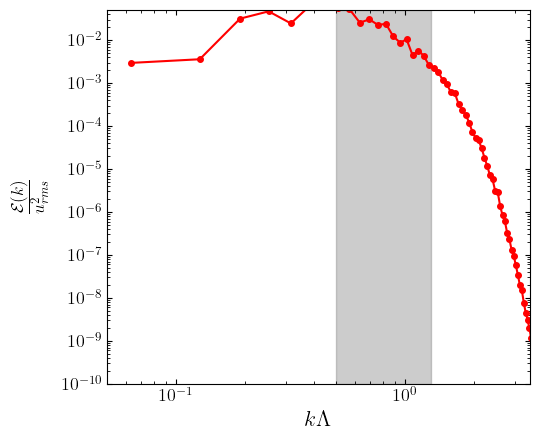

In [11]:
# =============================================================================
# 8. POST-PROCESSING: NORMALISED DIENSIONLESS ENERGY SPECTRUM
# =============================================================================
print("\nSimulation complete. Generating normalized energy spectrum profile...")

k_f = np.sqrt(Gamma2 / (2.0 * Gamma4)) 
Lambda = 1.0 / k_f
# 1. Reconstruct real-space velocity vectors to compute total u_rms^2 variance
u = np.real(ifft2(Dy * Om_hat))
v = np.real(ifft2(-Dx * Om_hat))
u_rms_sq = np.mean(u**2 + v**2)

# 2. Compute 2D Spectral Energy Density Map via Parseval's adjustments
norm_factor = (Nx * Ny)**2
E_2D = np.zeros_like(K2)
valid_modes = K2 > 0
E_2D[valid_modes] = 0.5 * np.abs(Om_hat[valid_modes])**2 / (K2[valid_modes] * norm_factor)

# 3. Perform Isotropic Shell Integration (Binning radial waves)
k_radial = np.sqrt(Kx_raw**2 + Ky_raw**2)
k_max = int(Nx / 4)  # Cutoff bound defined cleanly by our dealiasing filter
k_bins = np.arange(1, k_max)
E_k = np.zeros_like(k_bins, dtype=float)

for i, k in enumerate(k_bins):
    shell_mask = (k_radial >= k - 0.5) & (k_radial < k + 0.5)
    E_k[i] = np.sum(E_2D[shell_mask])

# 4. Map scales to dimensionless quantities matching the paper
k_scaled = k_bins * Lambda                  # Horizontal axis: k * Lambda
E_normalized = E_k / u_rms_sq               # Vertical axis: E(k) / u_rms^2

# =============================================================================
# 9. RENDER PANEL (E) PLOT SPECIFICATIONS
# =============================================================================
fig_spec, ax_spec = plt.subplots(figsize=(5.5, 4.5))

# Plot normalized data points using a red line with circular markers ('r-o')
ax_spec.loglog(k_scaled, E_normalized, 'r-o', markersize=4, linewidth=1.5, label=r'Active Spectrum')

# Shaded grey band indicating the inertial cascade range, matching the reference image
ax_spec.axvspan(0.5, 1.3, color='gray', alpha=0.4)

# Set scientific axis label formatting matching Panel (e)
ax_spec.set_xlabel(r'$k\Lambda$', fontsize=16)
ax_spec.set_ylabel(r'$\frac{\mathcal{E}(k)}{u_{rms}^2}$', fontsize=18, labelpad=10)

# Configure enclosed borders with inward-facing ticks on all four side lines
ax_spec.tick_params(top=True, right=True, which='both', direction='in', labelsize=13)
ax_spec.set_xlim(5e-2, 3.5)
ax_spec.set_ylim(1e-10, 5e-2)

plt.tight_layout()
plt.show()